In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import os


PATH="../data/processed/"
REPORTS="../reports/"

os.makedirs(REPORTS,exist_ok=True)


nav=pd.read_csv(PATH+"clean_nav_history.csv")
perf=pd.read_csv(PATH+"clean_performance.csv")
trans=pd.read_csv(PATH+"clean_transactions.csv")


nav["date"]=pd.to_datetime(nav["date"])
trans["date"]=pd.to_datetime(trans["date"])

In [2]:
fig=px.line(
    nav,
    x="date",
    y="nav",
    color="scheme_code",
    title="NAV Trend"
)

fig.show()


fig.write_image(
    REPORTS+"nav_trend.png"
)

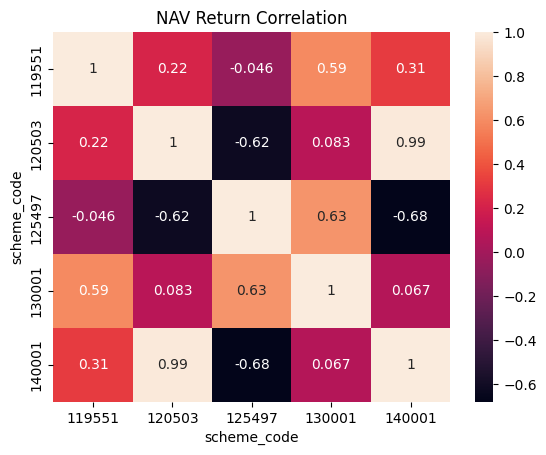

In [3]:

nav_table=nav.pivot(
    index="date",
    columns="scheme_code",
    values="nav"
)


returns=nav_table.pct_change()


corr=returns.corr()


sns.heatmap(
    corr,
    annot=True
)

plt.title(
"NAV Return Correlation"
)

plt.savefig(
REPORTS+"nav_correlation.png"
)

plt.show()

In [4]:
trans["transaction_type"].value_counts()

transaction_type
buy     2
sell    1
Name: count, dtype: int64

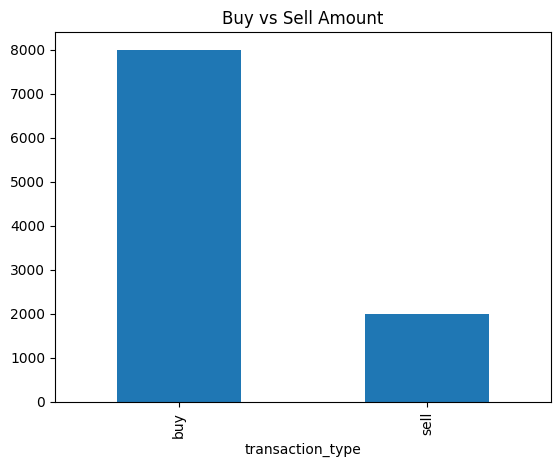

In [5]:
type_amount=trans.groupby(
"transaction_type"
)["amount"].sum()


type_amount.plot(
kind="bar"
)

plt.title(
"Buy vs Sell Amount"
)

plt.savefig(
REPORTS+"transaction_type.png"
)

plt.show()

In [6]:
monthly_transaction = (
    trans.groupby(
        trans["date"].dt.to_period("M")
    )["amount"]
    .sum()
)


monthly_transaction.index = (
    monthly_transaction.index.astype(str)
)


fig = px.line(
    x=monthly_transaction.index,
    y=monthly_transaction.values,
    title="Monthly Transaction Amount Trend"
)


fig.show()


fig.write_image(
    REPORTS+"monthly_transaction.png"
)

In [7]:
monthly=trans.groupby(
trans["date"].dt.to_period("M")
)["amount"].sum()


monthly.index=monthly.index.astype(str)


fig=px.line(
x=monthly.index,
y=monthly.values,
title="Monthly Transaction Amount"
)

fig.show()

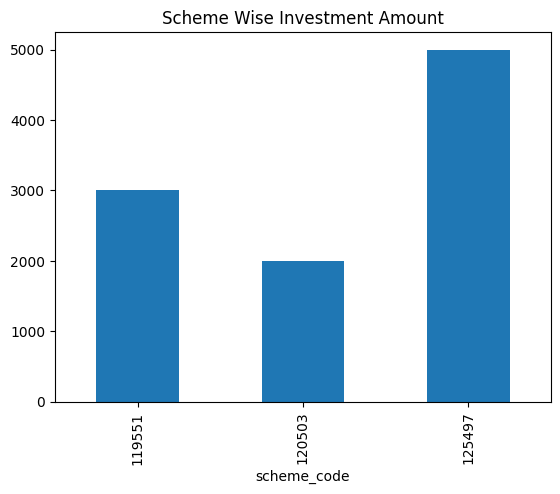

In [8]:
scheme_amount=trans.groupby(
"scheme_code"
)["amount"].sum()


scheme_amount.plot(
kind="bar"
)


plt.title(
"Scheme Wise Investment Amount"
)


plt.savefig(
REPORTS+"scheme_amount.png"
)


plt.show()

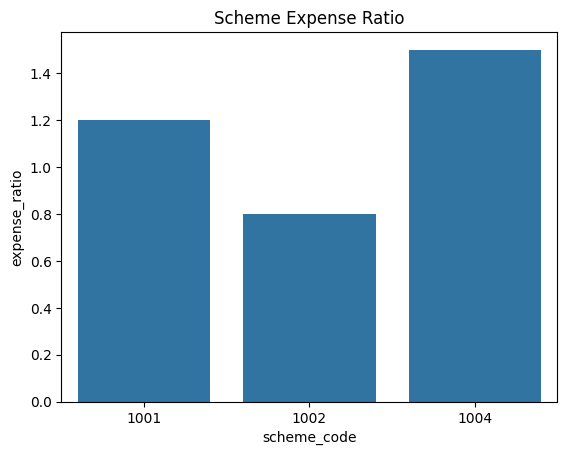

In [9]:
sns.barplot(
data=perf,
x="scheme_code",
y="expense_ratio"
)


plt.title(
"Scheme Expense Ratio"
)


plt.savefig(
REPORTS+"expense_ratio.png"
)


plt.show()

In [10]:
print(nav.shape)
print(trans.shape)

(25, 3)
(3, 5)


In [11]:
nav.info()
perf.info()
trans.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   scheme_code  25 non-null     int64         
 1   date         25 non-null     datetime64[us]
 2   nav          25 non-null     float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 732.0 bytes
<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   scheme_code    3 non-null      int64  
 1   expense_ratio  3 non-null      float64
dtypes: float64(1), int64(1)
memory usage: 180.0 bytes
<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    3 non-null      int64         
 1   scheme_code   

In [12]:
# EDA Key Findings

#1. NAV trends show daily movement across different mutual fund schemes.

#2. Return calculations help measure scheme performance changes.

#3. Correlation analysis identifies relationships between scheme NAV movements.

#4. Buy and sell transaction analysis shows investor activity patterns.

#5. Monthly transaction trends show changes in investment volume.

#6. Scheme-wise analysis identifies higher participation schemes.

#7. Expense ratio comparison highlights cost differences between funds.

#8. Lower expense ratios indicate potentially lower investment costs.

#9. Combined NAV and transaction analysis provides better fund insights.

#10. Cleaned datasets are ready for visualization and dashboard development.